**1. Data Loading and Preparation**

In [4]:
# === Cell 1: Import Libraries ===

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Display settings
pd.set_option('display.max_columns', None)
pd.set_option('display.float_format', lambda x: f'{x:.3f}')

# Plot style
sns.set_theme(style='whitegrid', font_scale=1.05)

In [5]:
# === Cell 2: Load Dataset ===

df = pd.read_csv('/content/Smart_Farming_Crop_Yield_2024.csv')

# Preview first five rows
df.head()

,farm_id,region,crop_type,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,irrigation_type,fertilizer_type,pesticide_usage_ml,sowing_date,harvest_date,total_days,yield_kg_per_hectare,sensor_id,timestamp,latitude,longitude,NDVI_index,crop_disease_status
0,FARM0001,North India,Wheat,35.950,5.990,17.790,75.620,77.030,7.270,NaN,Organic,6.340,2024-01-08,2024-05-09,122,4408.070,SENS0001,2024-03-19,14.971,82.998,0.630,Mild
1,FARM0002,South USA,Soybean,19.740,7.240,30.180,89.910,61.130,5.670,Sprinkler,Inorganic,9.600,2024-02-04,2024-05-26,112,5389.980,SENS0002,2024-04-21,16.613,70.869,0.580,NaN
2,FARM0003,South USA,Wheat,29.320,7.160,27.370,265.430,68.870,8.230,Drip,Mixed,15.260,2024-02-03,2024-06-26,144,2931.160,SENS0003,2024-02-28,19.503,79.068,0.800,Mild
3,FARM0004,Central USA,Maize,17.330,6.030,33.730,212.010,70.460,5.030,Sprinkler,Organic,25.800,2024-02-21,2024-07-04,134,4227.800,SENS0004,2024-05-14,31.071,85.520,0.440,NaN
4,FARM0005,Central USA,Cotton,19.370,5.920,33.860,269.090,55.730,7.930,NaN,Mixed,25.650,2024-02-05,2024-05-20,105,4979.960,SENS0005,2024-04-13,16.569,81.692,0.840,Severe


In [12]:
# === Cell 3: Basic Dataset Inspection ===

print("Dataset shape:", df.shape)

print("\nData types:")
display(df.dtypes)

print("\nMissing values:")
display(df.isnull().sum())

print("\nDuplicated rows:", df.duplicated().sum())

Dataset shape: (500, 22)

Data types:


,0
farm_id,object
region,object
crop_type,object
soil_moisture_%,float64
soil_pH,float64
temperature_C,float64
rainfall_mm,float64
humidity_%,float64
sunlight_hours,float64
irrigation_type,object



Missing values:


,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,150



Duplicated rows: 0


In [56]:
# === Cell 4: Data Cleaning and Preparation ===

df_clean = df.copy()

# Convert date columns into datetime format
date_cols = ['sowing_date', 'harvest_date', 'timestamp']

for col in date_cols:
    df_clean[col] = pd.to_datetime(df_clean[col], errors='coerce')

# Create crop growth duration
df_clean['growth_days'] = (
    df_clean['harvest_date'] - df_clean['sowing_date']
).dt.days

# Fill missing categorical values with "Unknown"
categorical_missing_cols = ['irrigation_type', 'crop_disease_status']

for col in categorical_missing_cols:
    df_clean[col] = df_clean[col].fillna('Unknown')

# Drop duplicated rows if any
df_clean = df_clean.drop_duplicates()

print("Cleaned dataset shape:", df_clean.shape)

print("\nRemaining missing values:")
display(df_clean.isnull().sum())

Cleaned dataset shape: (500, 23)

Remaining missing values:


,0
farm_id,0
region,0
crop_type,0
soil_moisture_%,0
soil_pH,0
temperature_C,0
rainfall_mm,0
humidity_%,0
sunlight_hours,0
irrigation_type,0


In [11]:
# === Cell 5: Define Column Groups ===

numeric_cols = [
    'soil_moisture_%',
    'soil_pH',
    'temperature_C',
    'rainfall_mm',
    'humidity_%',
    'sunlight_hours',
    'pesticide_usage_ml',
    'total_days',
    'yield_kg_per_hectare',
    'latitude',
    'longitude',
    'NDVI_index'
]

categorical_cols = [
    'region',
    'crop_type',
    'irrigation_type',
    'fertilizer_type',
    'crop_disease_status'
]

# Check summary statistics
print("Numerical Summary:")
display(df_clean[numeric_cols].describe())

print("\nCategorical Summary:")
display(df_clean[categorical_cols].describe())

Numerical Summary:


,soil_moisture_%,soil_pH,temperature_C,rainfall_mm,humidity_%,sunlight_hours,pesticide_usage_ml,total_days,yield_kg_per_hectare,latitude,longitude,NDVI_index
count,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000,500.000
mean,26.750,6.524,24.676,181.686,65.194,7.030,26.587,119.496,4032.927,22.442,80.392,0.602
std,10.150,0.586,5.349,72.293,14.643,1.692,13.202,16.798,1174.433,7.283,5.911,0.175
min,10.160,5.510,15.000,50.170,40.230,4.010,5.050,90.000,2023.560,10.004,70.020,0.300
25%,17.890,6.030,20.295,119.218,51.865,5.668,14.945,105.750,2994.820,16.263,75.375,0.448
50%,25.855,6.530,24.655,191.545,65.685,6.995,25.980,119.000,4071.690,21.982,80.650,0.610
75%,36.023,7.040,29.090,239.035,77.995,8.470,38.005,134.000,5062.110,28.529,85.655,0.750
max,44.980,7.500,34.840,298.960,90.000,10.000,49.940,150.000,5998.290,34.982,89.992,0.900



Categorical Summary:


,region,crop_type,irrigation_type,fertilizer_type,crop_disease_status
count,500,500,500,500,500
unique,5,5,4,3,4
top,Central USA,Maize,Unknown,Inorganic,Severe
freq,109,111,150,167,133


**2. Exploratory Data Analysis (EDA)**

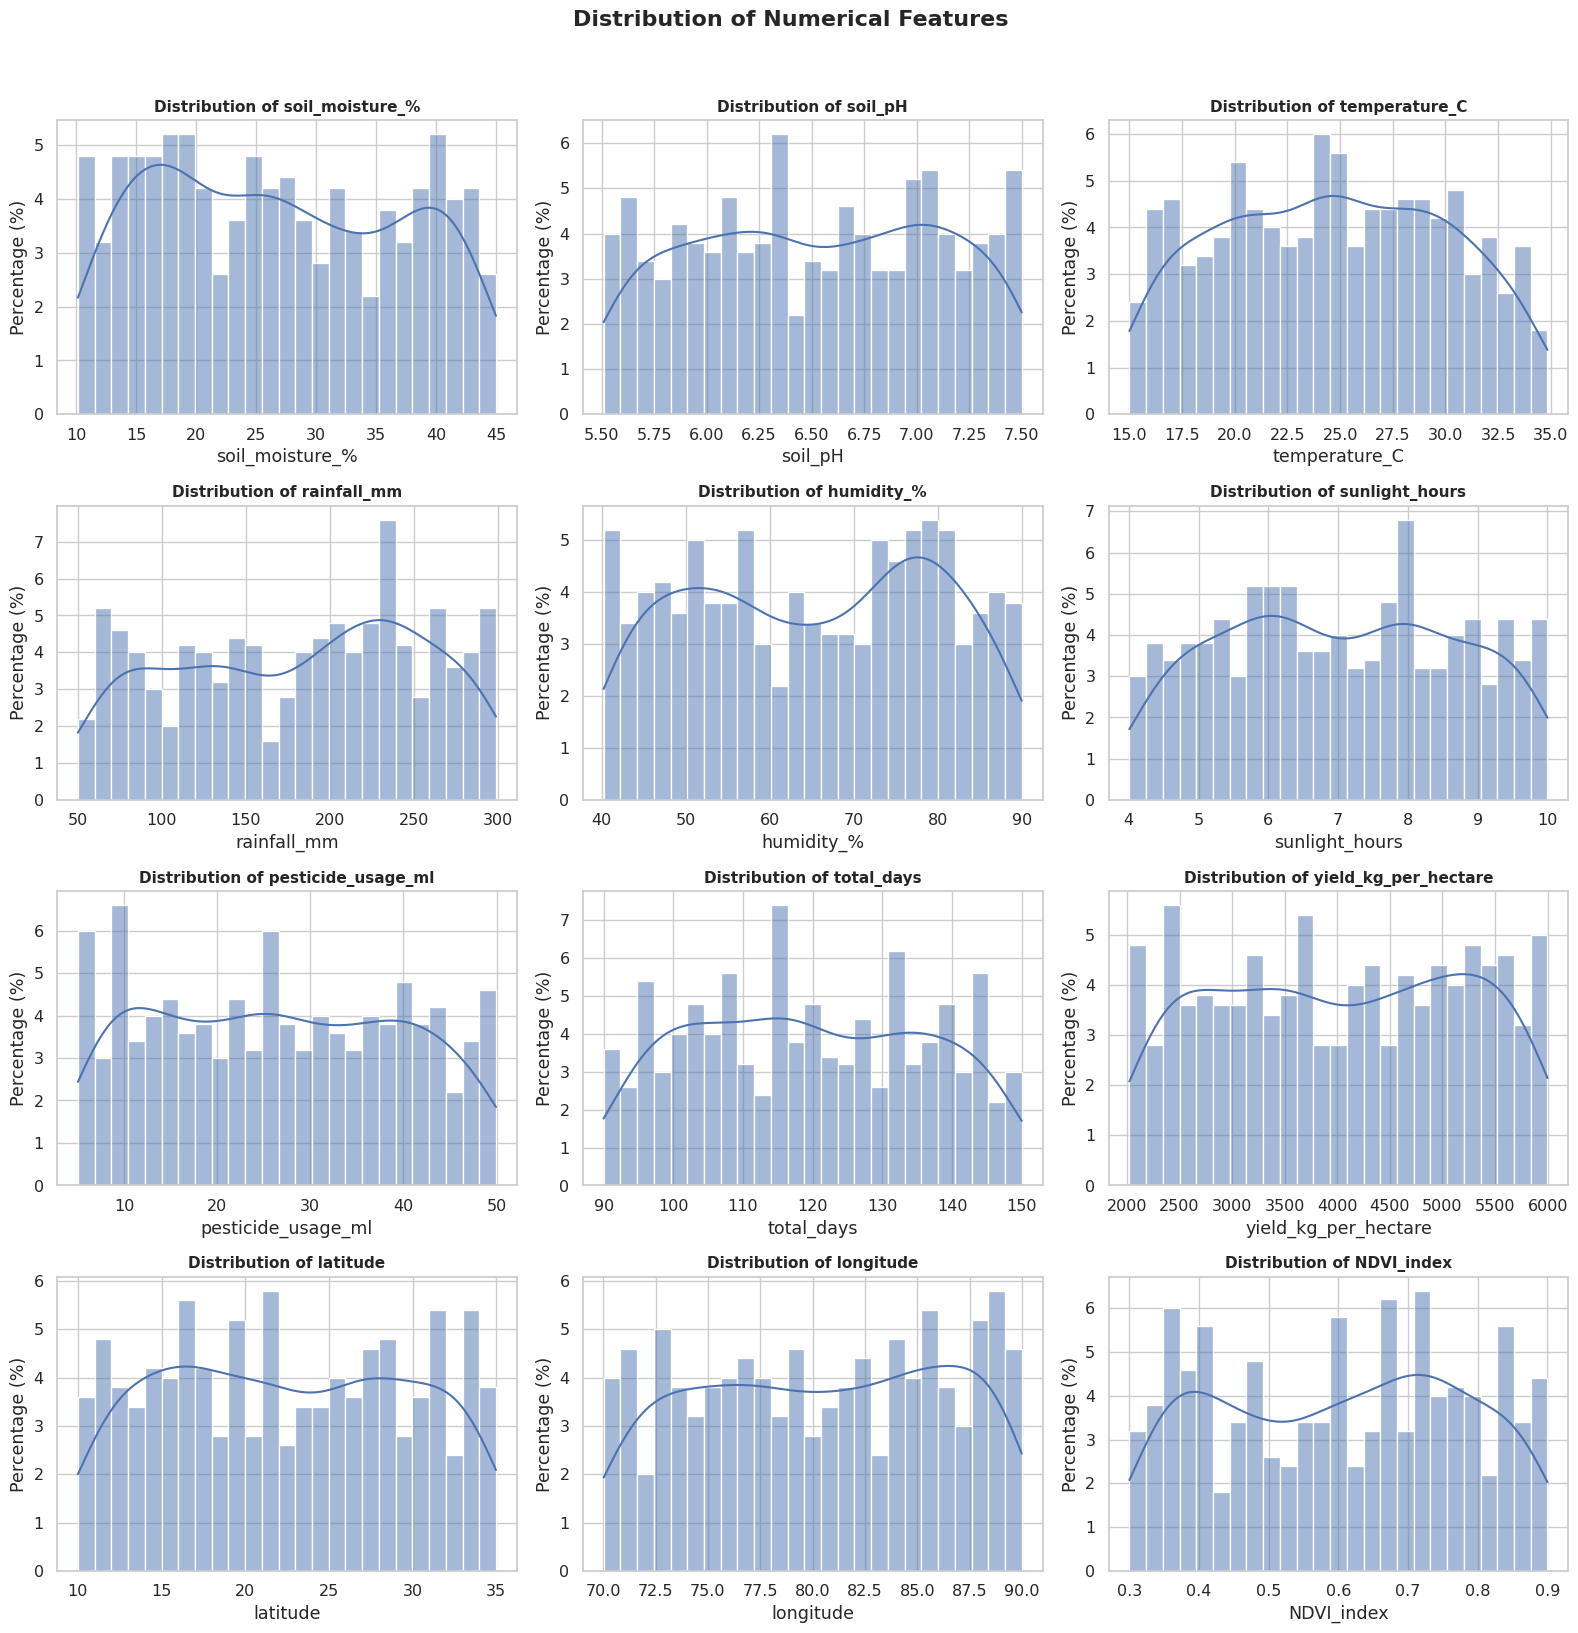

In [13]:
# === Cell 6: Full Distribution Histograms ===

n_cols = 3
n_rows = int(np.ceil(len(numeric_cols) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(16, 4 * n_rows))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    sns.histplot(
        data=df_clean,
        x=col,
        bins=25,
        kde=True,
        stat='percent',
        ax=axes[i]
    )
    axes[i].set_title(f'Distribution of {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Percentage (%)')

# Remove empty subplot spaces
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribution of Numerical Features', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

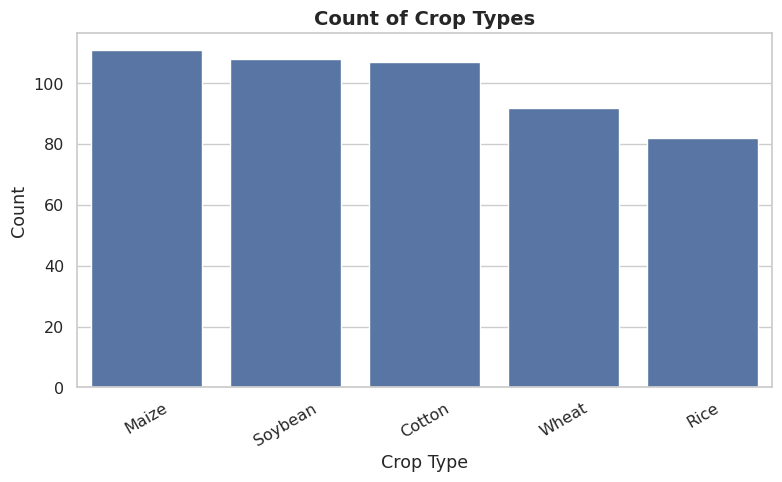

In [14]:
# === Cell 7: Crop Type Count Breakdown ===

plt.figure(figsize=(8, 5))

crop_order = df_clean['crop_type'].value_counts().index

sns.countplot(
    data=df_clean,
    x='crop_type',
    order=crop_order
)

plt.title('Count of Crop Types', fontsize=14, fontweight='bold')
plt.xlabel('Crop Type')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.tight_layout()
plt.show()

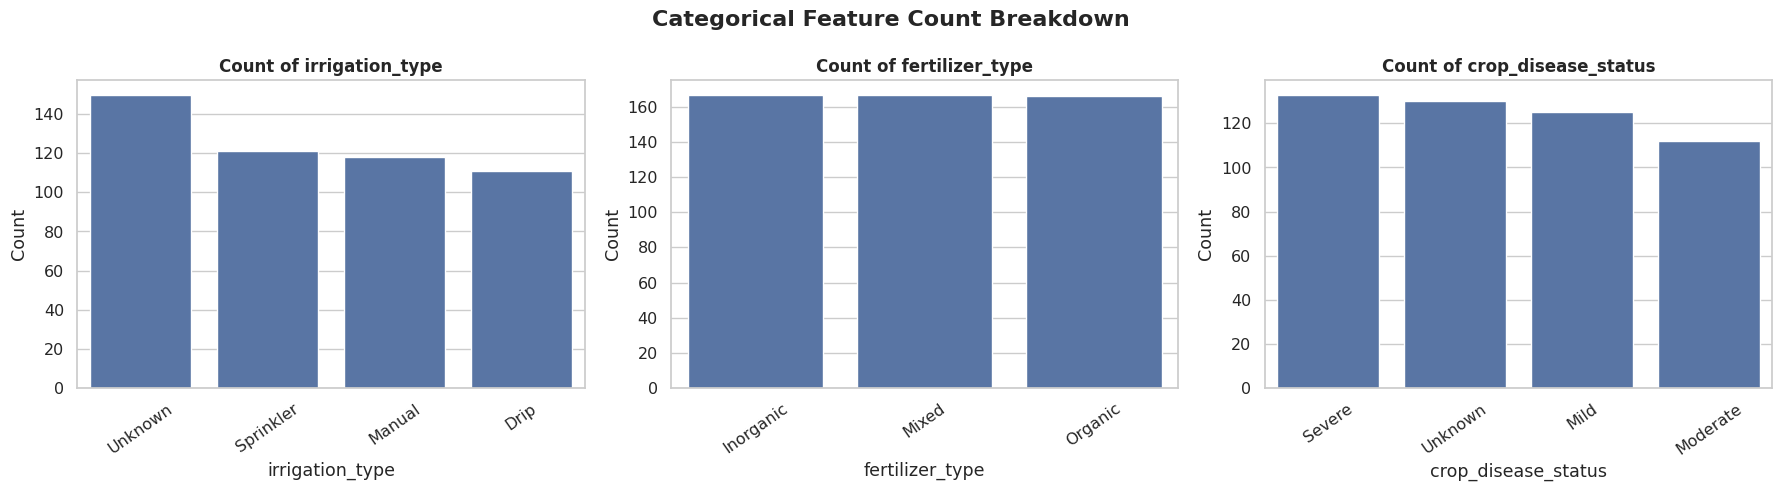

In [15]:
# === Cell 8: Irrigation, Fertilizer and Disease Status Count Breakdown ===

selected_categorical_cols = [
    'irrigation_type',
    'fertilizer_type',
    'crop_disease_status'
]

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, col in zip(axes, selected_categorical_cols):
    order = df_clean[col].value_counts().index

    sns.countplot(
        data=df_clean,
        x=col,
        order=order,
        ax=ax
    )

    ax.set_title(f'Count of {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')
    ax.tick_params(axis='x', rotation=35)

plt.suptitle('Categorical Feature Count Breakdown', fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()

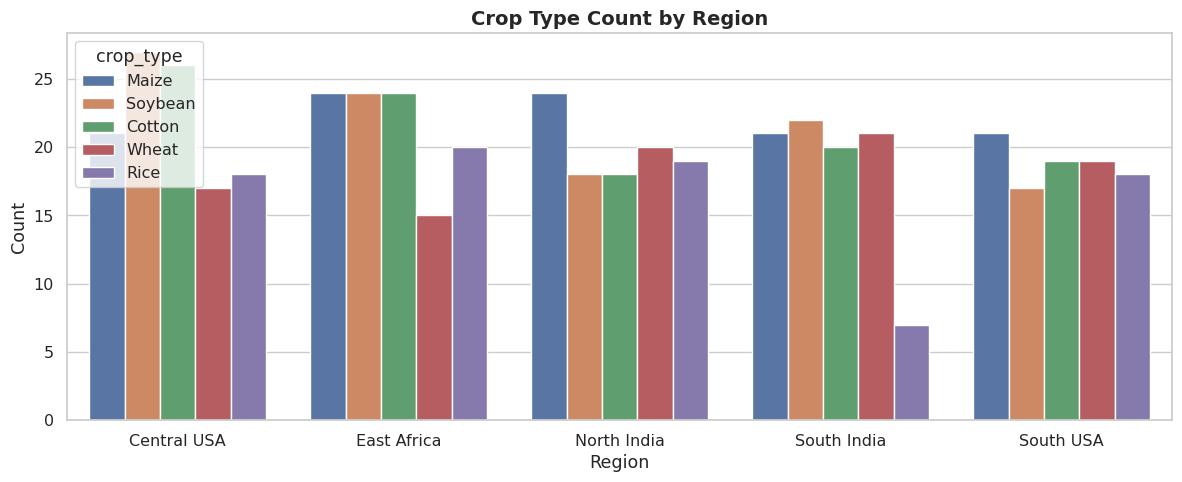

In [59]:
# === Cell 9: Crop Type Count by Region ===

plt.figure(figsize=(12, 5))

region_order = sorted(df_clean['region'].unique())
crop_order = df_clean['crop_type'].value_counts().index

sns.countplot(
    data=df_clean,
    x='region',
    hue='crop_type',
    order=region_order,
    hue_order=crop_order
)

plt.title('Crop Type Count by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=0)
plt.legend(title='crop_type', loc='upper left')

plt.tight_layout()
plt.show()

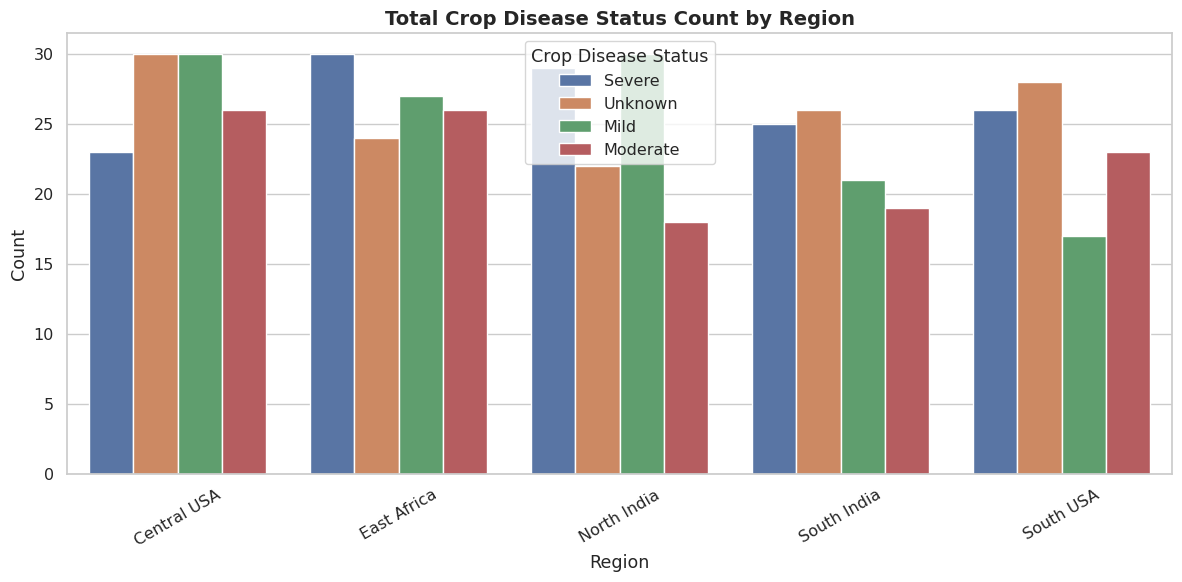

In [58]:
# === Cell 10: Total Crop Disease Status Count by Region ===

disease_order = df_clean['crop_disease_status'].value_counts().index

plt.figure(figsize=(12, 6))

sns.countplot(
    data=df_clean,
    x='region',
    hue='crop_disease_status',
    order=region_order,
    hue_order=disease_order
)

plt.title('Total Crop Disease Status Count by Region', fontsize=14, fontweight='bold')
plt.xlabel('Region')
plt.ylabel('Count')
plt.xticks(rotation=30)
plt.legend(title='Crop Disease Status')
plt.tight_layout()
plt.show()

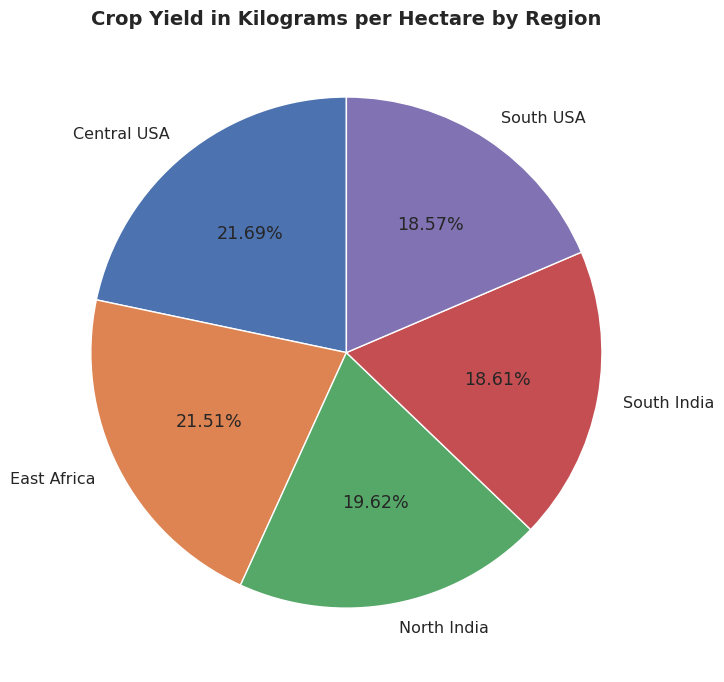

In [19]:
# === Cell 11: Pie Chart of Crop Yield per Hectare by Region ===

yield_by_region = (
    df_clean
    .groupby('region')['yield_kg_per_hectare']
    .sum()
    .sort_values(ascending=False)
)

plt.figure(figsize=(9, 7))

plt.pie(
    yield_by_region,
    labels=yield_by_region.index,
    autopct='%1.2f%%',
    startangle=90,
    wedgeprops={'edgecolor': 'white'}
)

plt.title(
    'Crop Yield in Kilograms per Hectare by Region',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

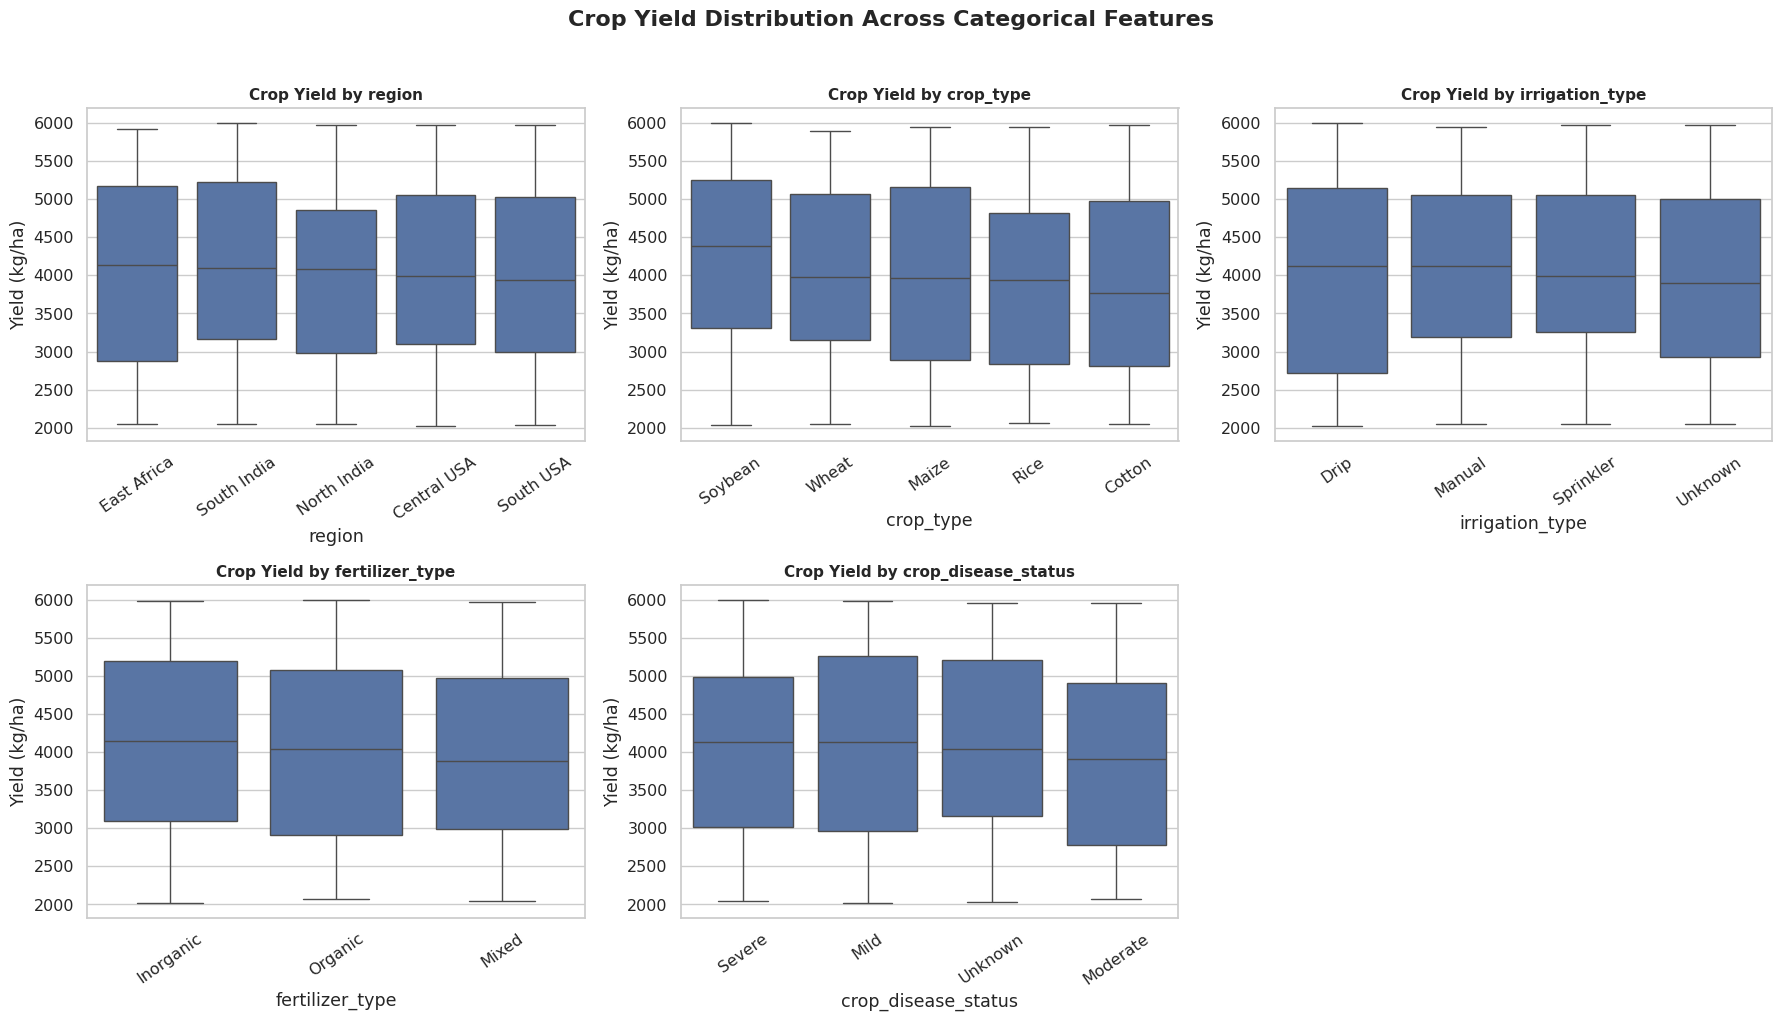

In [28]:
# === Cell 12: Boxplots of Yield by Categorical Features ===

yield_categorical_cols = [
    'region',
    'crop_type',
    'irrigation_type',
    'fertilizer_type',
    'crop_disease_status'
]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for i, col in enumerate(yield_categorical_cols):
    order = df_clean.groupby(col)['yield_kg_per_hectare'].median().sort_values(ascending=False).index

    sns.boxplot(
        data=df_clean,
        x=col,
        y='yield_kg_per_hectare',
        order=order,
        ax=axes[i]
    )

    axes[i].set_title(f'Crop Yield by {col}', fontsize=11, fontweight='bold')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Yield (kg/ha)')
    axes[i].tick_params(axis='x', rotation=35)

# Remove unused subplot
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle(
    'Crop Yield Distribution Across Categorical Features',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.tight_layout()
plt.show()

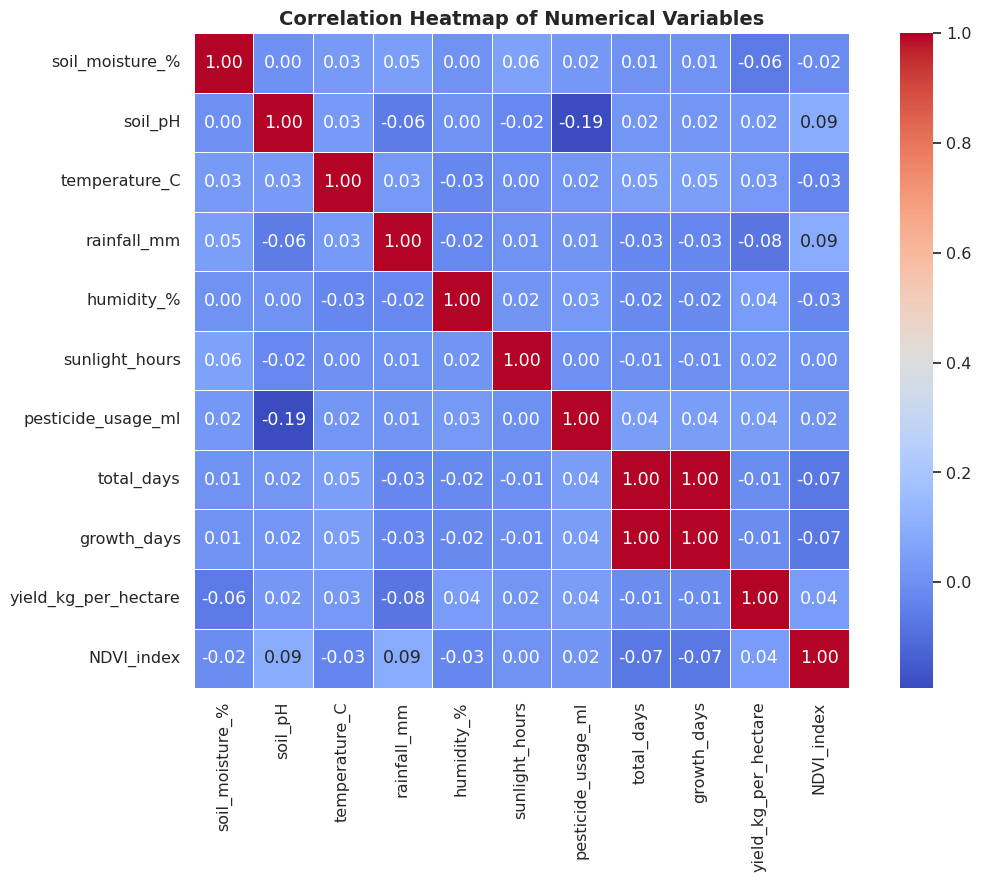

In [29]:
# === Cell 13: Correlation Heatmap of Numerical Features ===

correlation_cols = [
    'soil_moisture_%',
    'soil_pH',
    'temperature_C',
    'rainfall_mm',
    'humidity_%',
    'sunlight_hours',
    'pesticide_usage_ml',
    'total_days',
    'growth_days',
    'yield_kg_per_hectare',
    'NDVI_index'
]

corr_matrix = df_clean[correlation_cols].corr()

plt.figure(figsize=(12, 9))

sns.heatmap(
    corr_matrix,
    annot=True,
    fmt='.2f',
    cmap='coolwarm',
    linewidths=0.5,
    square=True
)

plt.title(
    'Correlation Heatmap of Numerical Variables',
    fontsize=14,
    fontweight='bold'
)

plt.tight_layout()
plt.show()

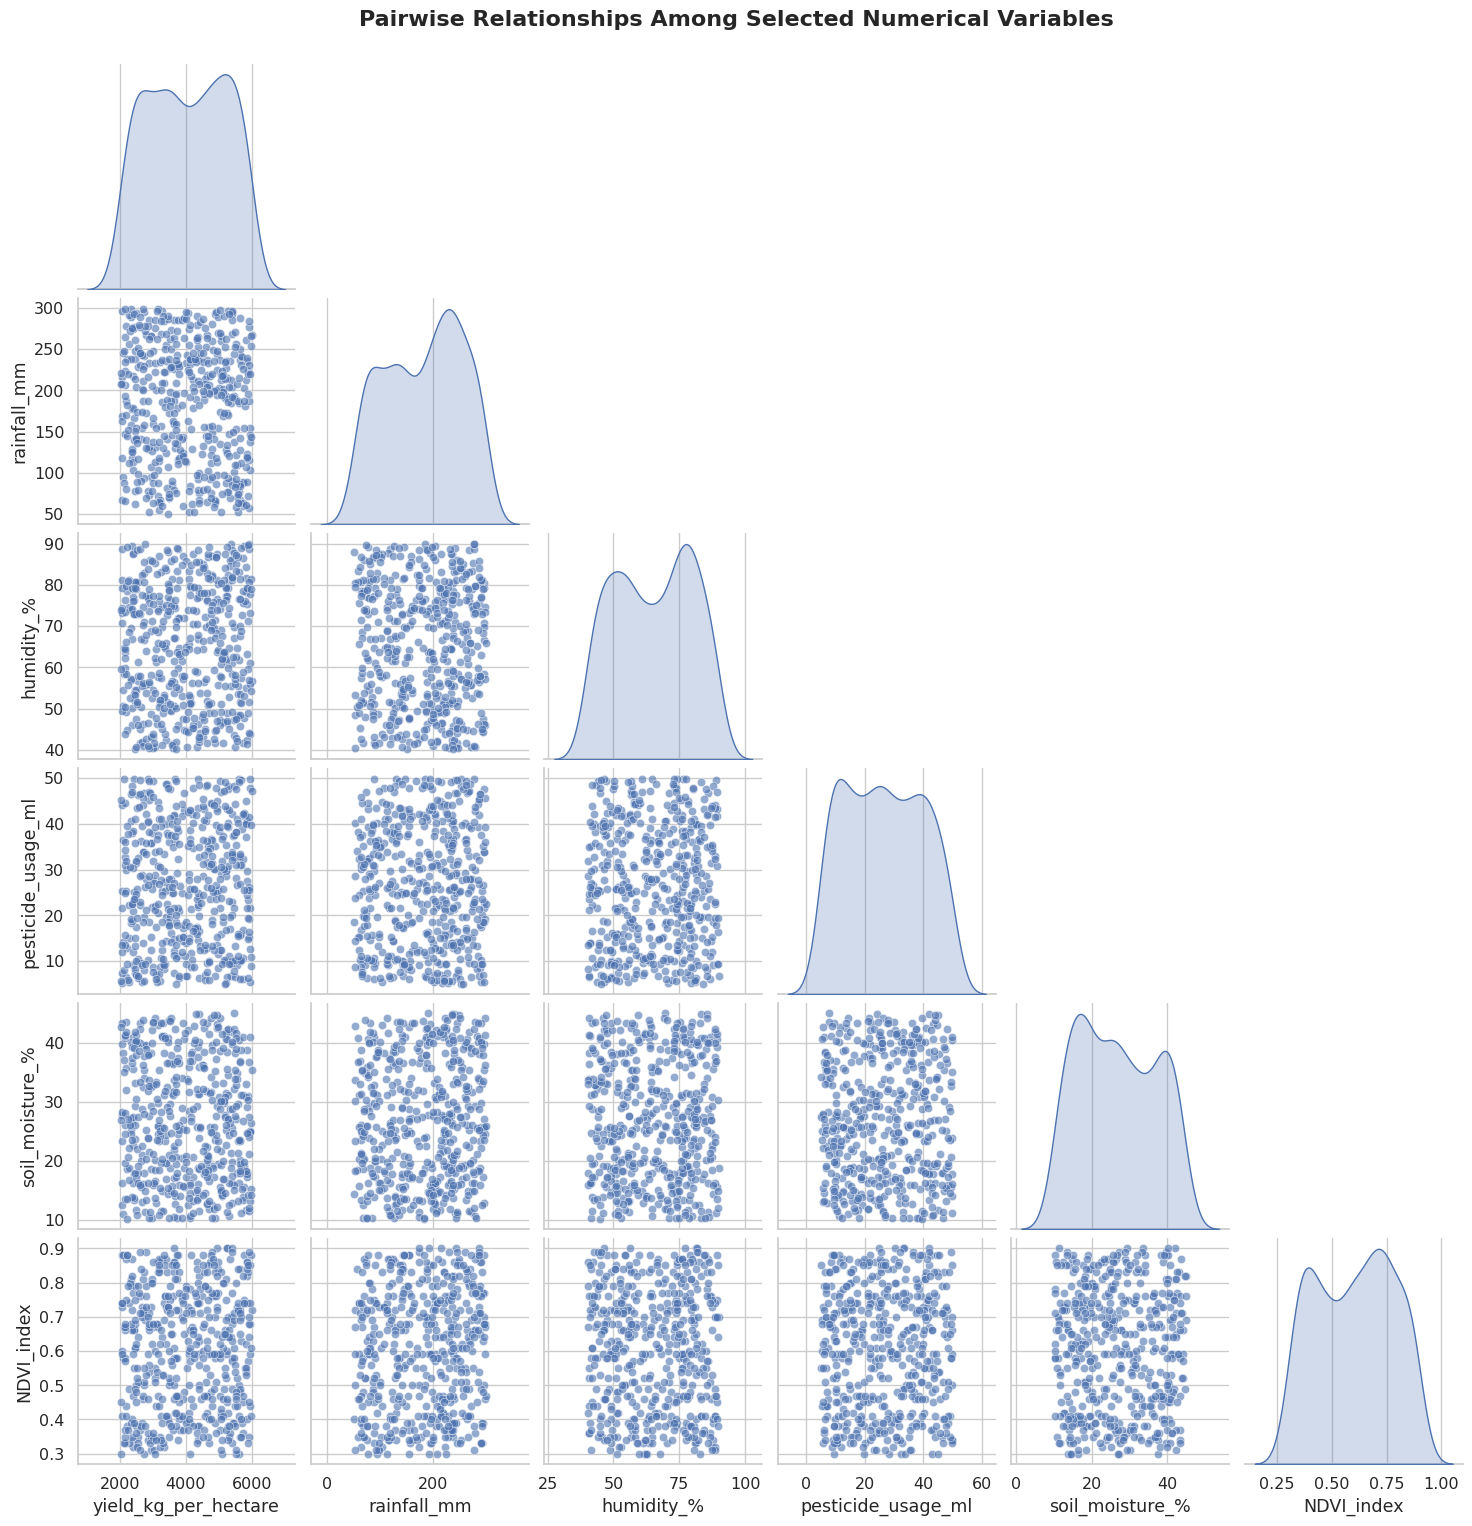

In [33]:
# === Cell 14: Pairplot of Selected Important Variables ===

selected_pairplot_cols = [
    'yield_kg_per_hectare',
    'rainfall_mm',
    'humidity_%',
    'pesticide_usage_ml',
    'soil_moisture_%',
    'NDVI_index'
]

sns.pairplot(
    df_clean[selected_pairplot_cols],
    kind='scatter',
    diag_kind='kde',
    corner=True,
    plot_kws={'alpha': 0.6}
)

plt.suptitle(
    'Pairwise Relationships Among Selected Numerical Variables',
    fontsize=16,
    fontweight='bold',
    y=1.02
)

plt.show()

**3. Statistical Hypothesis Testing**


=== One-Way ANOVA: Yield by rainfall_band ===


,count,mean,std,median
rainfall_band,,,,
Low,167,4127.686,1188.596,4170.370
Medium,166,4048.642,1196.200,4141.740
High,167,3922.548,1135.613,3942.560


F-statistic: 1.2976
p-value: 2.7412e-01
Result: No statistically significant difference between groups.


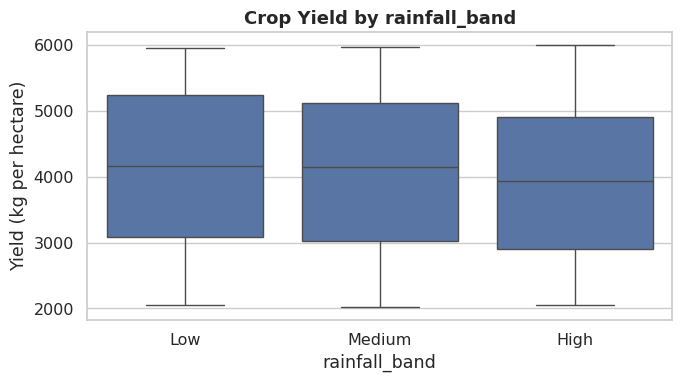


=== One-Way ANOVA: Yield by humidity_band ===


,count,mean,std,median
humidity_band,,,,
Low,167,4003.347,1147.332,3997.670
Medium,166,3957.269,1168.667,3902.860
High,167,4137.712,1206.073,4335.940


F-statistic: 1.0624
p-value: 3.4641e-01
Result: No statistically significant difference between groups.


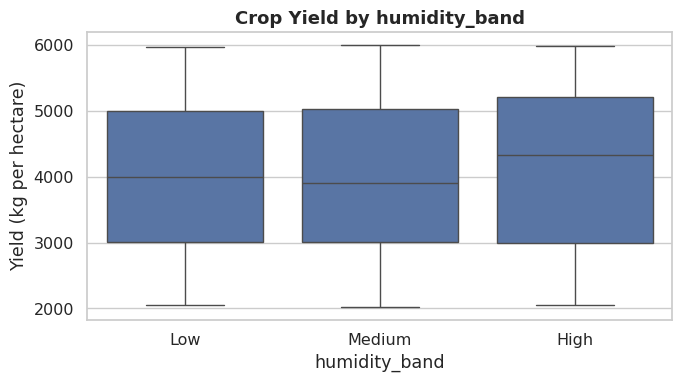


=== One-Way ANOVA: Yield by pesticide_usage_band ===


,count,mean,std,median
pesticide_usage_band,,,,
Low,168,4007.896,1169.516,3995.105
Medium,165,4029.977,1193.885,4097.140
High,167,4061.023,1166.428,4130.330


F-statistic: 0.0861
p-value: 9.1747e-01
Result: No statistically significant difference between groups.


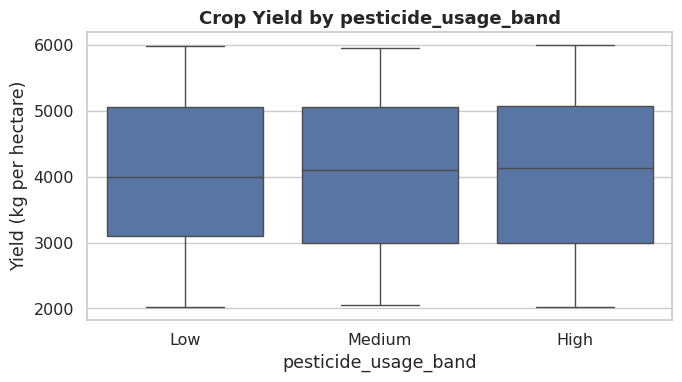


=== One-Way ANOVA: Yield by soil_moisture_band ===


,count,mean,std,median
soil_moisture_band,,,,
Low,167,4132.158,1165.897,4137.090
Medium,166,4069.257,1193.432,4049.120
High,167,3897.584,1158.240,3774.900


F-statistic: 1.7901
p-value: 1.6802e-01
Result: No statistically significant difference between groups.


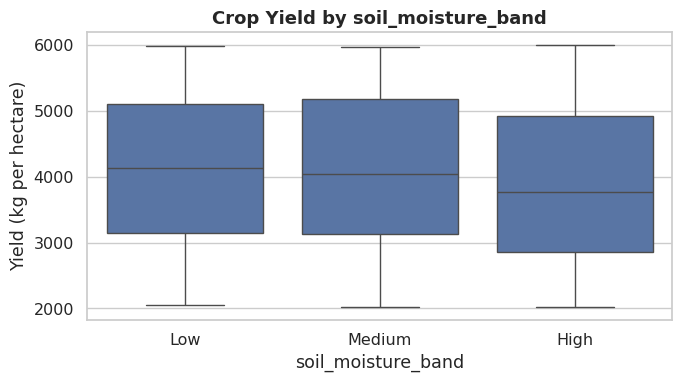

In [51]:
# === Cell 15: One-Way ANOVA - Environmental Bands vs Yield ===

from scipy import stats
from statsmodels.stats.multicomp import pairwise_tukeyhsd
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

df_stat = df_clean.copy()

# Create Low / Medium / High bands using pd.cut
band_variables = {
    'rainfall_mm': 'rainfall_band',
    'humidity_%': 'humidity_band',
    'pesticide_usage_ml': 'pesticide_usage_band',
    'soil_moisture_%': 'soil_moisture_band'
}

for original_col, band_col in band_variables.items():
    bins = [
        df_stat[original_col].min(),
        df_stat[original_col].quantile(1/3),
        df_stat[original_col].quantile(2/3),
        df_stat[original_col].max()
    ]

    df_stat[band_col] = pd.cut(
        df_stat[original_col],
        bins=bins,
        labels=['Low', 'Medium', 'High'],
        include_lowest=True
    )

# Run One-Way ANOVA for each environmental band
for band_col in band_variables.values():
    print(f"\n=== One-Way ANOVA: Yield by {band_col} ===")

    temp = df_stat[[band_col, 'yield_kg_per_hectare']].dropna()

    # Group summary
    summary = (
        temp
        .groupby(band_col, observed=True)['yield_kg_per_hectare']
        .agg(['count', 'mean', 'std', 'median'])
    )
    display(summary.round(3))

    # Prepare groups
    groups = [
        group['yield_kg_per_hectare'].values
        for name, group in temp.groupby(band_col, observed=True)
    ]

    # ANOVA
    f_stat, p_val = stats.f_oneway(*groups)

    print(f"F-statistic: {f_stat:.4f}")
    print(f"p-value: {p_val:.4e}")

    if p_val < 0.05:
        print("Result: Significant difference exists between groups.")

        tukey = pairwise_tukeyhsd(
            endog=temp['yield_kg_per_hectare'],
            groups=temp[band_col],
            alpha=0.05
        )

        print("\nTukey HSD Post-hoc Test:")
        print(tukey)
    else:
        print("Result: No statistically significant difference between groups.")

    # Visualization
    plt.figure(figsize=(7, 4))
    sns.boxplot(
        data=temp,
        x=band_col,
        y='yield_kg_per_hectare',
        order=['Low', 'Medium', 'High']
    )
    plt.title(f'Crop Yield by {band_col}', fontsize=13, fontweight='bold')
    plt.xlabel(band_col)
    plt.ylabel('Yield (kg per hectare)')
    plt.tight_layout()
    plt.show()


=== Chi-Square Test: rainfall_band vs crop_disease_status ===


crop_disease_status,Mild,Moderate,Severe
rainfall_band,,,
Low,42,47,35
Medium,33,30,55
High,50,35,43


Chi-square statistic: 11.8889
Degrees of freedom: 4
p-value: 1.8197e-02
Cramer's V: 0.1268
Result: Significant association exists.


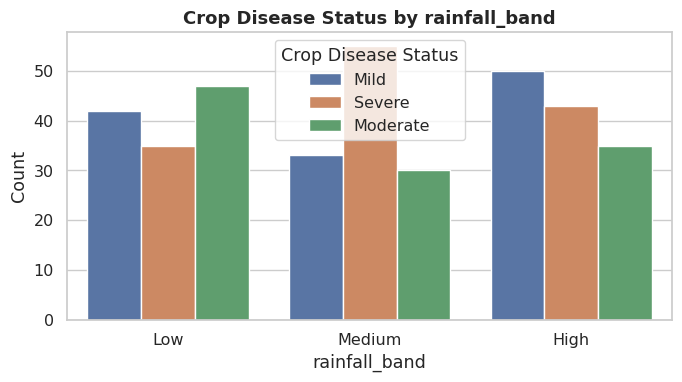


=== Chi-Square Test: humidity_band vs crop_disease_status ===


crop_disease_status,Mild,Moderate,Severe
humidity_band,,,
Low,40,37,47
Medium,43,39,43
High,42,36,43


Chi-square statistic: 0.4052
Degrees of freedom: 4
p-value: 9.8205e-01
Cramer's V: 0.0234
Result: No statistically significant association.


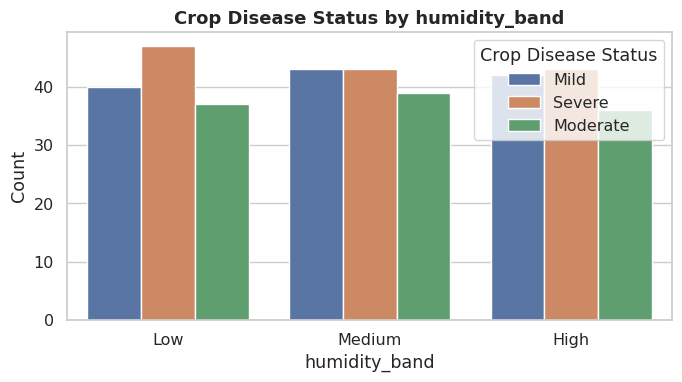


=== Chi-Square Test: pesticide_usage_band vs crop_disease_status ===


crop_disease_status,Mild,Moderate,Severe
pesticide_usage_band,,,
Low,40,37,49
Medium,42,40,36
High,43,35,48


Chi-square statistic: 2.5155
Degrees of freedom: 4
p-value: 6.4186e-01
Cramer's V: 0.0583
Result: No statistically significant association.


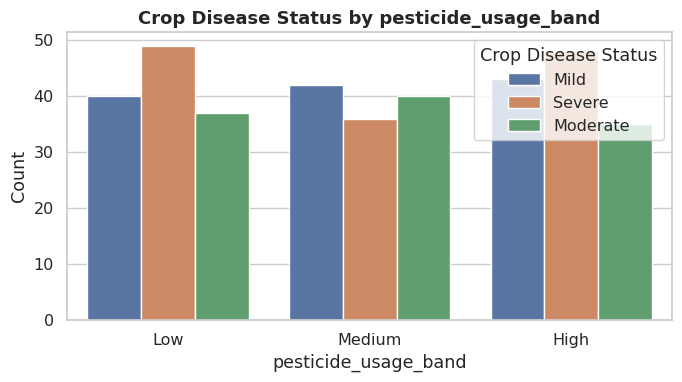


=== Chi-Square Test: soil_moisture_band vs crop_disease_status ===


crop_disease_status,Mild,Moderate,Severe
soil_moisture_band,,,
Low,46,39,40
Medium,39,39,44
High,40,34,49


Chi-square statistic: 2.0064
Degrees of freedom: 4
p-value: 7.3458e-01
Cramer's V: 0.0521
Result: No statistically significant association.


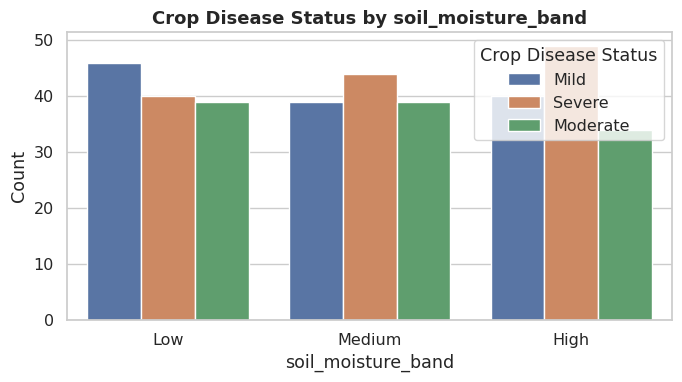

In [52]:
# === Cell 16: Chi-Square Test - Environmental Bands vs Crop Disease Status ===

from scipy.stats import chi2_contingency

def cramers_v(contingency_table):
    chi2, p, dof, expected = chi2_contingency(contingency_table)
    n = contingency_table.sum().sum()
    min_dim = min(contingency_table.shape) - 1
    return np.sqrt(chi2 / (n * min_dim))

environmental_bands = [
    'rainfall_band',
    'humidity_band',
    'pesticide_usage_band',
    'soil_moisture_band'
]

for band_col in environmental_bands:
    print(f"\n=== Chi-Square Test: {band_col} vs crop_disease_status ===")

    temp = df_stat[[band_col, 'crop_disease_status']].dropna()

    # Optional: remove Unknown if it represents missing disease status
    temp = temp[temp['crop_disease_status'] != 'Unknown']

    contingency_table = pd.crosstab(
        temp[band_col],
        temp['crop_disease_status']
    )

    display(contingency_table)

    chi2, p_val, dof, expected = chi2_contingency(contingency_table)
    cv = cramers_v(contingency_table)

    print(f"Chi-square statistic: {chi2:.4f}")
    print(f"Degrees of freedom: {dof}")
    print(f"p-value: {p_val:.4e}")
    print(f"Cramer's V: {cv:.4f}")

    if p_val < 0.05:
        print("Result: Significant association exists.")
    else:
        print("Result: No statistically significant association.")

    # Visualization
    plt.figure(figsize=(7, 4))
    sns.countplot(
        data=temp,
        x=band_col,
        hue='crop_disease_status',
        order=['Low', 'Medium', 'High']
    )
    plt.title(f'Crop Disease Status by {band_col}', fontsize=13, fontweight='bold')
    plt.xlabel(band_col)
    plt.ylabel('Count')
    plt.legend(title='Crop Disease Status')
    plt.tight_layout()
    plt.show()

=== Two-Way ANOVA: Fertilizer Type × Irrigation Type ===


,sum_sq,df,F,PR(>F)
C(fertilizer_type),293698.882,2.000,0.107,0.898
C(irrigation_type),235530.077,2.000,0.086,0.917
C(fertilizer_type):C(irrigation_type),5094389.686,4.000,0.933,0.445
Residual,465695566.095,341.000,NaN,NaN



Mean Yield by Fertilizer Type and Irrigation Type:


irrigation_type,Drip,Manual,Sprinkler
fertilizer_type,,,
Inorganic,4116.410,3982.474,4207.687
Mixed,3908.532,3998.669,4175.991
Organic,4050.036,4238.362,3857.727


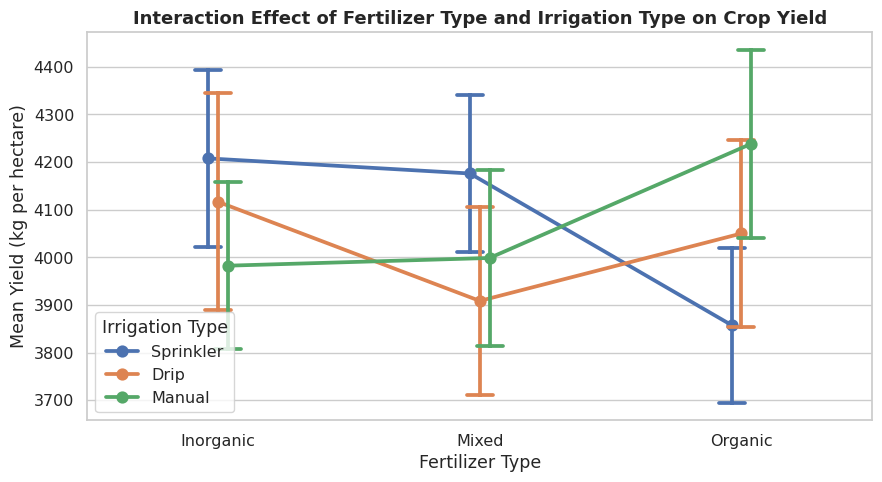

In [53]:
# === Cell 17: Two-Way ANOVA - Fertilizer Type × Irrigation Type on Yield ===

import statsmodels.api as sm
from statsmodels.formula.api import ols

# Prepare data
two_way_df = df_stat[
    ['fertilizer_type', 'irrigation_type', 'yield_kg_per_hectare']
].dropna()

# Remove Unknown irrigation if it was created from missing values
two_way_df = two_way_df[two_way_df['irrigation_type'] != 'Unknown']

# Two-Way ANOVA model
model = ols(
    'yield_kg_per_hectare ~ C(fertilizer_type) * C(irrigation_type)',
    data=two_way_df
).fit()

anova_table = sm.stats.anova_lm(model, typ=2)

print("=== Two-Way ANOVA: Fertilizer Type × Irrigation Type ===")
display(anova_table.round(4))

# Group mean table
print("\nMean Yield by Fertilizer Type and Irrigation Type:")
mean_table = two_way_df.pivot_table(
    values='yield_kg_per_hectare',
    index='fertilizer_type',
    columns='irrigation_type',
    aggfunc='mean'
)

display(mean_table.round(3))

# Interaction plot
plt.figure(figsize=(9, 5))

sns.pointplot(
    data=two_way_df,
    x='fertilizer_type',
    y='yield_kg_per_hectare',
    hue='irrigation_type',
    dodge=True,
    markers='o',
    capsize=0.1,
    errorbar='se'
)

plt.title(
    'Interaction Effect of Fertilizer Type and Irrigation Type on Crop Yield',
    fontsize=13,
    fontweight='bold'
)

plt.xlabel('Fertilizer Type')
plt.ylabel('Mean Yield (kg per hectare)')
plt.legend(title='Irrigation Type')
plt.tight_layout()
plt.show()

=== Shapiro-Wilk Test for Normality of Residuals ===
Statistic: 0.9511
p-value: 2.2617e-09
Result: Residuals do not appear to be normally distributed.


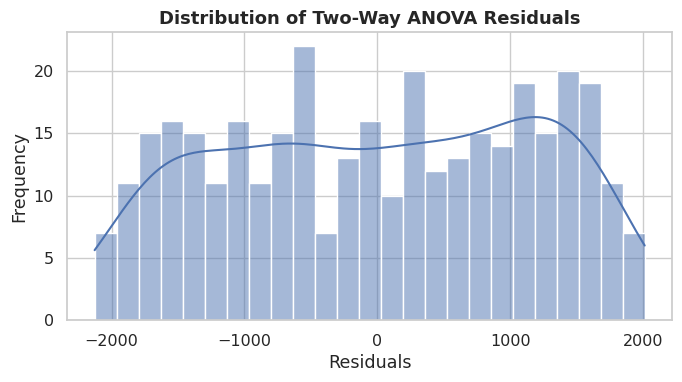

In [54]:
# === Cell 18: Shapiro-Wilk Test - Normality of Residuals ===

residuals = model.resid

shapiro_test = stats.shapiro(residuals)

print("=== Shapiro-Wilk Test for Normality of Residuals ===")
print(f"Statistic: {shapiro_test.statistic:.4f}")
print(f"p-value: {shapiro_test.pvalue:.4e}")

if shapiro_test.pvalue > 0.05:
    print("Result: Residuals appear to be normally distributed.")
else:
    print("Result: Residuals do not appear to be normally distributed.")

# Residual distribution plot
plt.figure(figsize=(7, 4))
sns.histplot(residuals, kde=True, bins=25)
plt.title('Distribution of Two-Way ANOVA Residuals', fontsize=13, fontweight='bold')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

In [55]:
# === Cell 19: Levene's Test - Homogeneity of Variance ===

# Create groups based on Fertilizer Type × Irrigation Type combination
levene_groups = [
    group['yield_kg_per_hectare'].values
    for name, group in two_way_df.groupby(['fertilizer_type', 'irrigation_type'], observed=True)
    if len(group) > 1
]

levene_test = stats.levene(*levene_groups)

print("=== Levene’s Test for Homogeneity of Variance ===")
print(f"Statistic: {levene_test.statistic:.4f}")
print(f"p-value: {levene_test.pvalue:.4e}")

if levene_test.pvalue > 0.05:
    print("Result: Variances are equal across groups.")
else:
    print("Result: Variances are not equal across groups.")

=== Levene’s Test for Homogeneity of Variance ===
Statistic: 0.8570
p-value: 5.5316e-01
Result: Variances are equal across groups.
